# Rolling Out-of-Sample Backtesting

The previous notebooks constructed and evaluated portfolios using historical data. However, evaluating an optimized portfolio on the same data used to estimate its weights can overstate its performance.

In this notebook, I use a rolling out-of-sample backtest. Portfolio weights are estimated using only past data and then held fixed during the following test year.

I compare three strategies:

1. Maximum-Sharpe portfolio
2. Equal-weight portfolio
3. S&P 500 benchmark

This framework provides a more realistic test of whether historical portfolio optimization translates into better subsequent performance.

## 1. Data

I use the same eight stocks as in the previous notebooks and the S&P 500 as a market benchmark.

Daily adjusted prices from 2016 through 2025 are converted into daily simple returns.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

In [19]:
tickers = [
    "AAPL",
    "MSFT",
    "JPM",
    "JNJ",
    "XOM",
    "PG",
    "CAT",
    "NEE"
]

benchmark_ticker = "^GSPC"

start_date = "2016-01-01"
end_date = "2026-01-01"

stock_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

benchmark_data = yf.download(
    benchmark_ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

prices = stock_data["Close"]
benchmark_prices = benchmark_data["Close"]

returns = prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

if isinstance(benchmark_returns, pd.DataFrame):
    benchmark_returns = benchmark_returns.squeeze()

returns.head()

Ticker,AAPL,CAT,JNJ,JPM,MSFT,NEE,PG,XOM
Date,,,,,,,,
2016-01-05,-0.025059,-0.010443,0.004180,0.001729,0.004562,0.009752,0.003190,0.008520
2016-01-06,-0.019570,-0.015755,-0.005054,-0.014436,-0.018165,-0.003251,-0.009667,-0.008320
2016-01-07,-0.042204,-0.034431,-0.011655,-0.040440,-0.034783,0.004413,-0.008734,-0.016006
2016-01-08,0.005288,-0.010166,-0.010683,-0.022399,0.003067,0.004489,-0.015678,-0.020202
2016-01-11,0.016192,-0.028756,-0.006010,-0.001527,-0.000573,0.003898,0.009214,-0.013389


## 2. Maximum-Sharpe Optimization Function

For each training window, I estimate expected annual returns and the annualized covariance matrix using only the observations in that window.

I then find the long-only portfolio with the highest estimated Sharpe ratio. Portfolio weights are constrained to lie between 0 and 1 and must sum to one.

The risk-free rate is assumed to be zero for consistency with the previous notebooks.

In [20]:
def optimize_max_sharpe(training_returns):
    mu = training_returns.mean() * 252
    cov_matrix = training_returns.cov() * 252

    n_assets = len(training_returns.columns)
    risk_free_rate = 0.0

    def negative_sharpe(weights):
        portfolio_return = weights @ mu
        portfolio_variance = weights @ cov_matrix @ weights
        portfolio_volatility = np.sqrt(portfolio_variance)

        sharpe_ratio = (
            (portfolio_return - risk_free_rate)
            / portfolio_volatility
        )

        return -sharpe_ratio

    constraints = {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    }

    bounds = [(0, 1)] * n_assets
    initial_weights = np.ones(n_assets) / n_assets

    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )

    if not result.success:
        raise RuntimeError(
            f"Optimization failed: {result.message}"
        )

    return result.x

## 3. Rolling Backtest Design

I use a four-year rolling estimation window followed by a one-year out-of-sample test period.

The procedure is:

- 2016–2019 training → 2020 testing
- 2017–2020 training → 2021 testing
- 2018–2021 training → 2022 testing
- 2019–2022 training → 2023 testing
- 2020–2023 training → 2024 testing
- 2021–2024 training → 2025 testing

At the beginning of each test year, the maximum-Sharpe portfolio is re-estimated using only the preceding four years of returns. The estimated weights are then held fixed throughout the test year.

This prevents future test-period returns from entering the portfolio construction process.

In [21]:
test_years = range(2020, 2026)

optimized_returns_list = []
equal_weight_returns_list = []
benchmark_returns_list = []

weights_history = {}

n_assets = len(tickers)
equal_weights = np.ones(n_assets) / n_assets

for test_year in test_years:
    train_start = test_year - 4
    train_end = test_year - 1

    training_returns = returns[
        (returns.index.year >= train_start)
        & (returns.index.year <= train_end)
    ]

    testing_returns = returns[
        returns.index.year == test_year
    ]

    optimized_weights = optimize_max_sharpe(
        training_returns
    )

    weights_history[test_year] = optimized_weights

    optimized_daily_returns = (
        testing_returns @ optimized_weights
    )

    equal_weight_daily_returns = (
        testing_returns @ equal_weights
    )

    benchmark_daily_returns = benchmark_returns[
        benchmark_returns.index.year == test_year
    ]

    optimized_returns_list.append(
        optimized_daily_returns
    )

    equal_weight_returns_list.append(
        equal_weight_daily_returns
    )

    benchmark_returns_list.append(
        benchmark_daily_returns
    )

## 4. Out-of-Sample Return Series

I combine the yearly test-period returns into continuous out-of-sample return series covering 2020–2025.

Only returns observed after each portfolio was constructed are included.

In [22]:
optimized_returns = pd.concat(
    optimized_returns_list
).sort_index()

equal_weight_returns = pd.concat(
    equal_weight_returns_list
).sort_index()

benchmark_test_returns = pd.concat(
    benchmark_returns_list
).sort_index()

optimized_returns.name = "Maximum Sharpe"
equal_weight_returns.name = "Equal Weight"
benchmark_test_returns.name = "S&P 500"

backtest_returns = pd.concat(
    [
        optimized_returns,
        equal_weight_returns,
        benchmark_test_returns
    ],
    axis=1,
    join="inner"
)

backtest_returns.head()

,Maximum Sharpe,Equal Weight,S&P 500
Date,,,
2020-01-02,-0.000853,0.007868,0.008379
2020-01-03,-0.001477,-0.008559,-0.007060
2020-01-06,0.003666,0.002737,0.003533
2020-01-07,-0.005908,-0.006647,-0.002803
2020-01-08,0.004833,0.004661,0.004902


## 5. Cumulative Out-of-Sample Performance

I calculate the growth of $1 invested at the beginning of 2020.

Cumulative wealth shows the realized investment path of each strategy over the full out-of-sample period.

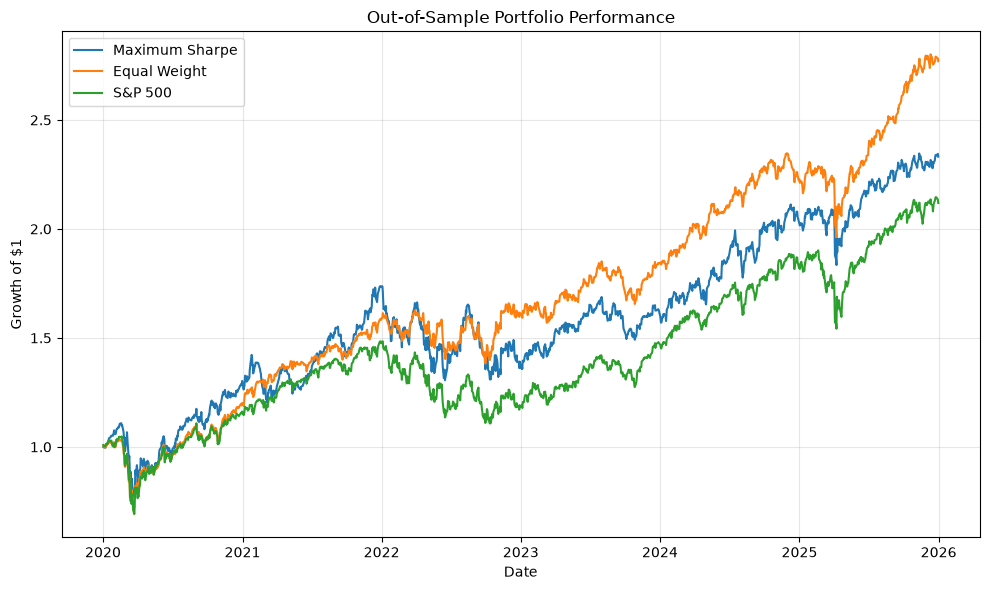

In [23]:
cumulative_wealth = (
    1 + backtest_returns
).cumprod()

plt.figure(figsize=(10, 6))

for strategy in cumulative_wealth.columns:
    plt.plot(
        cumulative_wealth.index,
        cumulative_wealth[strategy],
        label=strategy
    )

plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title(
    "Out-of-Sample Portfolio Performance"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 6. Out-of-Sample Performance Metrics

I compare the strategies using compound annual growth rate (CAGR), annualized volatility, Sharpe ratio, and maximum drawdown.

CAGR measures the realized compounded growth rate over the full test period, while maximum drawdown captures the largest peak-to-trough decline.

In [24]:
def performance_metrics(daily_returns):
    total_growth = (1 + daily_returns).prod()

    n_years = len(daily_returns) / 252

    cagr = (
        total_growth ** (1 / n_years)
    ) - 1

    annual_volatility = (
        daily_returns.std() * np.sqrt(252)
    )

    annualized_mean_return = (
        daily_returns.mean() * 252
    )

    sharpe_ratio = (
        annualized_mean_return
        / annual_volatility
    )

    cumulative = (
        1 + daily_returns
    ).cumprod()

    running_max = cumulative.cummax()

    drawdown = (
        cumulative / running_max
    ) - 1

    max_drawdown = drawdown.min()

    return pd.Series({
        "CAGR": cagr,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    })

In [25]:
performance = backtest_returns.apply(
    performance_metrics
).T

performance

,CAGR,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Maximum Sharpe,0.151950,0.238723,0.712025,-0.350358
Equal Weight,0.185579,0.195504,0.968795,-0.330507
S&P 500,0.133689,0.209226,0.704803,-0.339250


## 7. Annual Out-of-Sample Returns

Aggregate performance can hide substantial variation across market environments. I therefore calculate the realized return of each strategy separately for every test year.

In [26]:
annual_returns = backtest_returns.groupby(
    backtest_returns.index.year
).apply(
    lambda x: (1 + x).prod() - 1
)

annual_returns

,Maximum Sharpe,Equal Weight,S&P 500
Date,,,
2020,0.302260,0.201823,0.162589
2021,0.333620,0.317791,0.268927
2022,-0.201130,0.019238,-0.194428
2023,0.172498,0.140327,0.242305
2024,0.245908,0.210124,0.233090
2025,0.150328,0.243332,0.163878


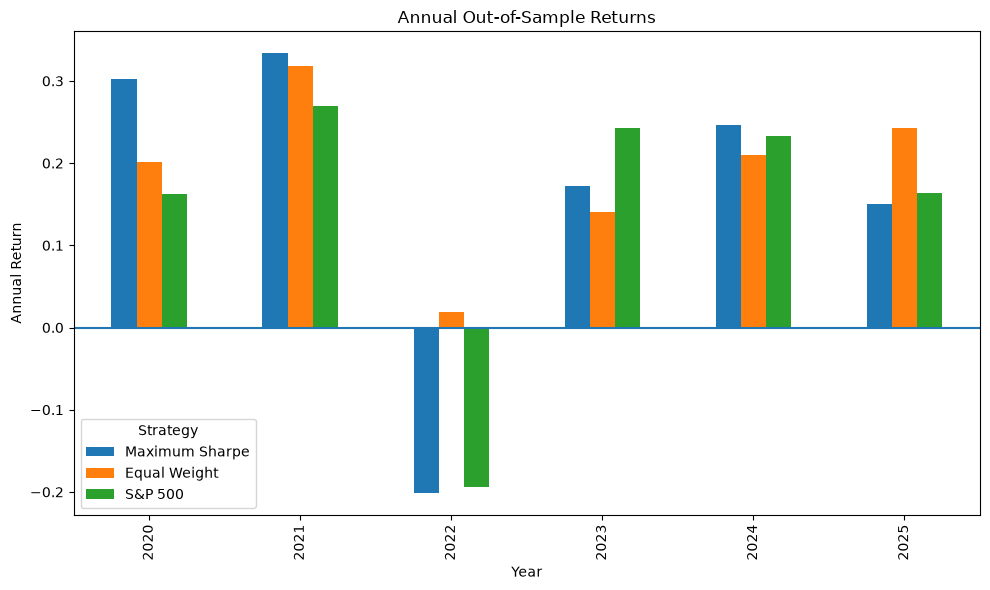

In [27]:
annual_returns.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Year")
plt.ylabel("Annual Return")
plt.title(
    "Annual Out-of-Sample Returns"
)
plt.axhline(0)
plt.legend(title="Strategy")
plt.tight_layout()

plt.show()

## 8. Portfolio Weight Stability

The maximum-Sharpe portfolio is re-estimated before every test year. I examine how the estimated weights change across training windows.

Large changes in portfolio weights may indicate sensitivity to the estimated expected returns and covariance matrix.

In [28]:
weights_df = pd.DataFrame(
    weights_history,
    index=tickers
).T

weights_df.index.name = "Test Year"

weights_df

,AAPL,MSFT,JPM,JNJ,XOM,PG,CAT,NEE
Test Year,,,,,,,,
2020,0.108318,0.028897,1.163228e-16,2.203061e-01,8.558248e-02,5.556662e-01,1.230783e-03,1.581049e-16
2021,0.419557,0.000000,0.000000e+00,4.677376e-17,1.497219e-01,4.307215e-01,0.000000e+00,1.254079e-17
2022,0.299119,0.000000,0.000000e+00,9.169743e-18,3.591603e-01,3.230672e-01,1.865397e-02,9.599687e-17
2023,0.443642,0.084665,0.000000e+00,8.173739e-17,1.802063e-17,1.461658e-01,2.004242e-01,1.251021e-01
2024,0.374703,0.315903,1.053067e-16,0.000000e+00,2.542334e-01,7.835280e-17,3.160804e-17,5.516122e-02
2025,0.060654,0.008766,0.000000e+00,1.492879e-01,2.076531e-01,1.194649e-16,1.692565e-01,4.043821e-01


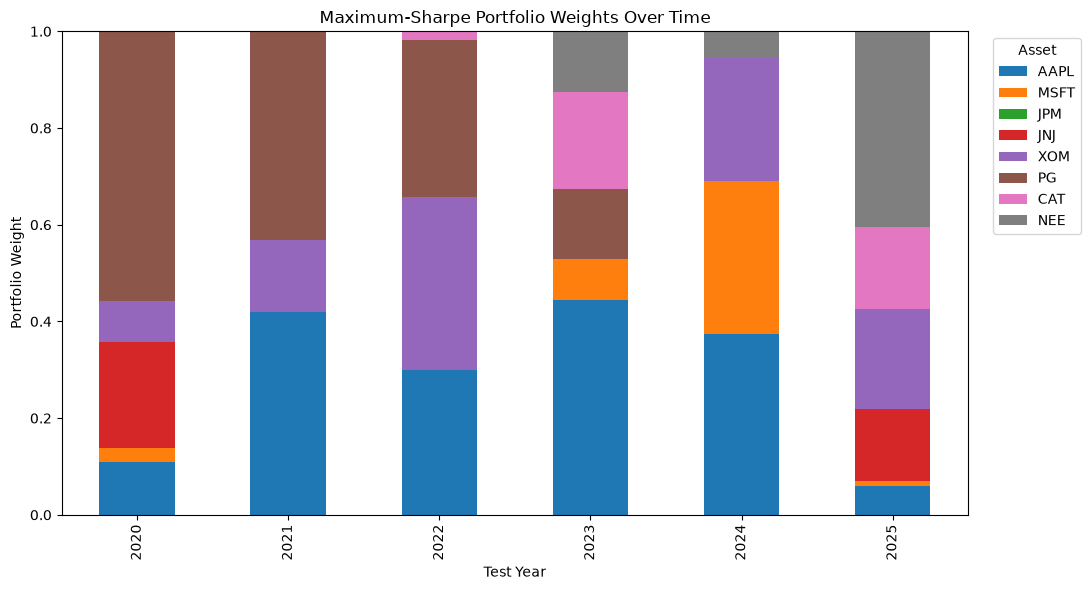

In [29]:
weights_df.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.xlabel("Test Year")
plt.ylabel("Portfolio Weight")
plt.title(
    "Maximum-Sharpe Portfolio Weights Over Time"
)

plt.legend(
    title="Asset",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 9. Portfolio Turnover

Large changes in optimized weights require portfolio rebalancing. I calculate turnover between consecutive annual allocations as a simple measure of trading intensity.

Higher turnover can make a strategy less practical once transaction costs are considered.

In [30]:
turnover = (
    weights_df.diff()
    .abs()
    .sum(axis=1, min_count=1)
    / 2
)

turnover.name = "Turnover"

turnover

Test Year
2020         NaN
2021    0.375378
2022    0.228092
2023    0.536062
2024    0.485471
2025    0.667765
Name: Turnover, dtype: float64

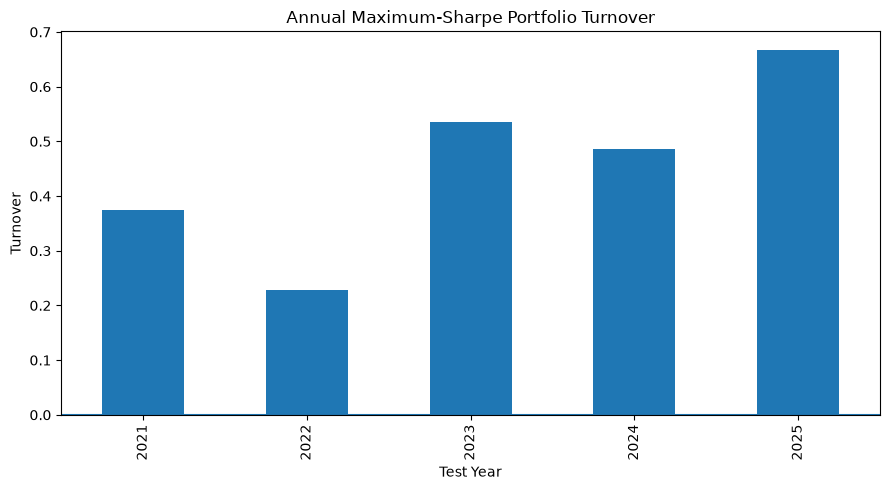

In [31]:
turnover.dropna().plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Test Year")
plt.ylabel("Turnover")
plt.title(
    "Annual Maximum-Sharpe Portfolio Turnover"
)
plt.axhline(0)
plt.tight_layout()

plt.show()

## 10. Out-of-Sample Drawdowns

I compare drawdowns during the test period to examine how each strategy behaved during periods of market stress.

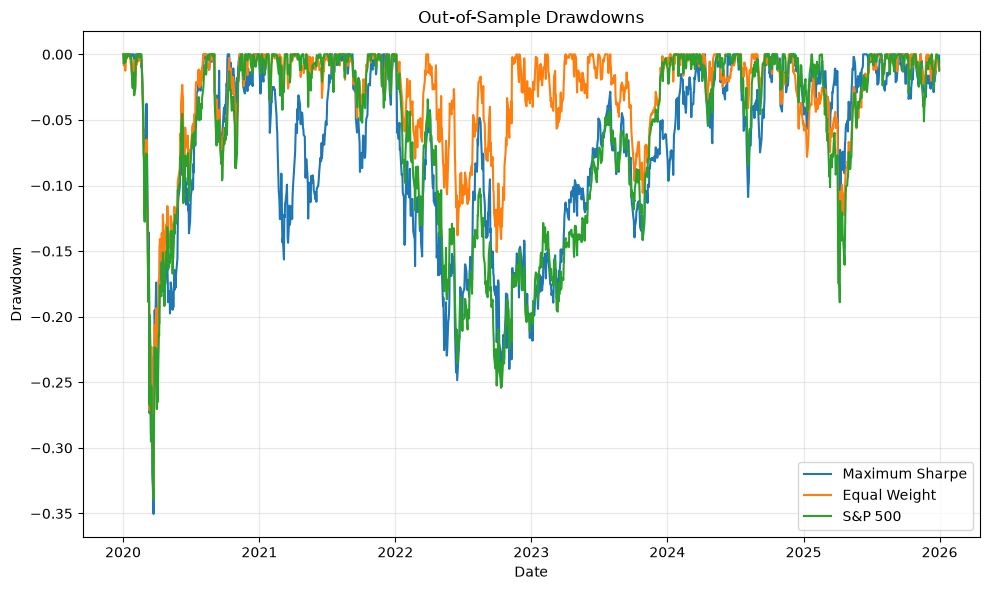

In [32]:
running_max = cumulative_wealth.cummax()

drawdowns = (
    cumulative_wealth / running_max
) - 1

plt.figure(figsize=(10, 6))

for strategy in drawdowns.columns:
    plt.plot(
        drawdowns.index,
        drawdowns[strategy],
        label=strategy
    )

plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.title(
    "Out-of-Sample Drawdowns"
)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

## 11. Conclusion

The rolling out-of-sample backtest shows that the maximum-Sharpe portfolio did not outperform the simpler equal-weight strategy over 2020–2025.

The equal-weight portfolio achieved the highest CAGR at 18.56%, compared with 15.20% for the maximum-Sharpe portfolio and 13.37% for the S&P 500. It also had the highest realized Sharpe ratio (0.97) and the lowest annualized volatility (19.55%). In contrast, the maximum-Sharpe portfolio had a Sharpe ratio of 0.71 and the highest volatility at 23.87%. Its maximum drawdown was also the largest of the three strategies at approximately 35.0%.

Performance varied substantially across years. The optimized portfolio performed particularly well in 2020 and 2021, but lost 20.11% in 2022 while the equal-weight portfolio remained slightly positive. It recovered in later years, but this was not sufficient to outperform the equal-weight strategy over the full test period.

The optimized weights also changed considerably across estimation windows. Several assets received weights close to zero in some years and large allocations in others. Annual turnover increased as high as approximately 66.8% by 2025. This suggests that the maximum-Sharpe solution is sensitive to changes in the estimated expected returns and covariance matrix.

Overall, the results show an important distinction between in-sample optimization and out-of-sample performance. A portfolio that is mathematically optimal using historical estimates does not necessarily remain optimal when market conditions change. In this sample, the simple equal-weight strategy was more robust than the maximum-Sharpe strategy despite requiring no estimation of expected returns or covariances.

The backtest still has several limitations. It ignores transaction costs and taxes, uses a fixed four-year estimation window and annual rebalancing frequency, assumes long-only positions, and relies on historical sample estimates of expected returns and covariances. The asset universe is also fixed in advance, so the results should be interpreted as an illustration of portfolio optimization rather than evidence of a universally superior investment strategy.